In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [25]:
data = pd.read_csv('../Data/gpt_4o_mini_sweep_task2_20260511_142222/task2_sweep_results.csv')

In [26]:
records = list(data.T.to_dict().values())

In [27]:
records[3]

{'community_a': 't5_3a3ge',
 'community_b': 't5_2u9xs',
 'coverage': 0.5,
 'input_comments': '[{\'comment_id\': 9026, \'text\': "Good god, another cringelord.\\n\\nWhy are you acting like it\'s your computer that\'s unprotected? It\'s not, so get the fuck off your high horse, you pathetic little man. \\n\\nIf he doesn\'t want to update his system to the latest security updates and he encounters and issue, then that\'s on him isn\'t it. As long as he browses in a safe and has a modicum of common sense then he\'ll be fine.\\n\\nPeople like you are beyond annoying. The type of people at parties that will come up to you and try and start an iPhone vs Android debate. Sad.", \'community\': \'t5_2u9xs\', \'status\': \'violation\'}, {\'comment_id\': 7534, \'text\': \'Let me help you go to c disk and find windows folder then inside it find system32 and press shift delete. FPS++\', \'community\': \'t5_2u9xs\', \'status\': \'violation\'}, {\'comment_id\': 11820, \'text\': \'[deleted]\', \'communi

In [33]:
BASE_METRICS = ["coverage", "redundancy", "violating_fraction", "unique_comments", "unique_comments_a", "unique_comments_b"]
norms = [5, 10]
task_name = "task2"

def plot_metrics(records, task_name=BASE_METRICS, norms=norms):
    if not records:
        print("No records to plot.")
        return

    sizes = sorted({r["n_samples"] for r in records})
    palette = plt.cm.tab10.colors

    metrics_to_plot = [m for m in BASE_METRICS
                       if m not in ('unique_comments', 'unique_comments_a', 'unique_comments_b')
                       and any(m in r and r[m] is not None for r in records)]

    n = len(metrics_to_plot) + 1
    cols = min(3, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4.5 * rows))
    axes_flat = np.array(axes).flatten() if n > 1 else [axes]

    for idx, metric in enumerate(metrics_to_plot):
        ax = axes_flat[idx]

        for n_idx, num_norms in enumerate(norms):
            color = palette[n_idx % len(palette)]
            norm_records = [r for r in records if r.get('num_norms') == num_norms]
            xs_mean, ys_mean, ys_std = [], [], []

            for size in sizes:
                vals = [r[metric] for r in norm_records
                        if r["n_samples"] == size and r.get(metric) is not None]
                if not vals:
                    continue
                xs_mean.append(size)
                ys_mean.append(float(np.mean(vals)))
                ys_std.append(float(np.std(vals)))

            if xs_mean:
                ys_mean_arr = np.array(ys_mean)
                ys_std_arr  = np.array(ys_std)
                ax.fill_between(xs_mean, ys_mean_arr - ys_std_arr, ys_mean_arr + ys_std_arr,
                                color=color, alpha=0.18, zorder=2)
                ax.plot(xs_mean, ys_mean_arr, "o-", linewidth=2.2, markersize=8,
                        color=color, zorder=4, label=f"norms={num_norms}")

        pretty = metric.replace("_", " ").title()
        ax.set_title(pretty, fontsize=13, fontweight="bold", pad=8)
        ax.set_xlabel("n_samples", fontsize=11)
        ax.set_ylabel(pretty, fontsize=11)
        ax.xaxis.set_major_locator(ticker.FixedLocator(sizes))
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.legend(fontsize=9)
        ax.set_ylim(bottom=0)

    ax = axes_flat[len(metrics_to_plot)]
    for label, metric, color, marker in [
        ('Both communities', 'unique_comments',   palette[3], 'o'),
        ('Community A',      'unique_comments_a', palette[0], 's'),
        ('Community B',      'unique_comments_b', palette[2], '^'),
    ]:
        xs_mean, ys_mean, ys_std = [], [], []
        for size in sizes:
            vals = [r[metric] for r in records
                    if r["n_samples"] == size and r.get(metric) is not None]
            if not vals:
                continue
            xs_mean.append(size)
            ys_mean.append(float(np.mean(vals)))
            ys_std.append(float(np.std(vals)))
        if xs_mean:
            ys_mean_arr = np.array(ys_mean)
            ys_std_arr  = np.array(ys_std)
            ax.fill_between(xs_mean, ys_mean_arr - ys_std_arr, ys_mean_arr + ys_std_arr,
                            color=color, alpha=0.18, zorder=2)
            ax.plot(xs_mean, ys_mean_arr, f"{marker}-", linewidth=2.2, markersize=8,
                color=color, zorder=4, label=label)

    ax.set_title("Unique Comments", fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel("n_samples", fontsize=11)
    ax.set_ylabel("Unique Comments", fontsize=11)
    ax.xaxis.set_major_locator(ticker.FixedLocator(sizes))
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    fig.suptitle(f"Metrics vs Sample Size  —  {task_name}",
                 fontsize=15, fontweight="bold", y=1.02)
    fig.tight_layout()
    # plt.close(fig)
    plt.show()

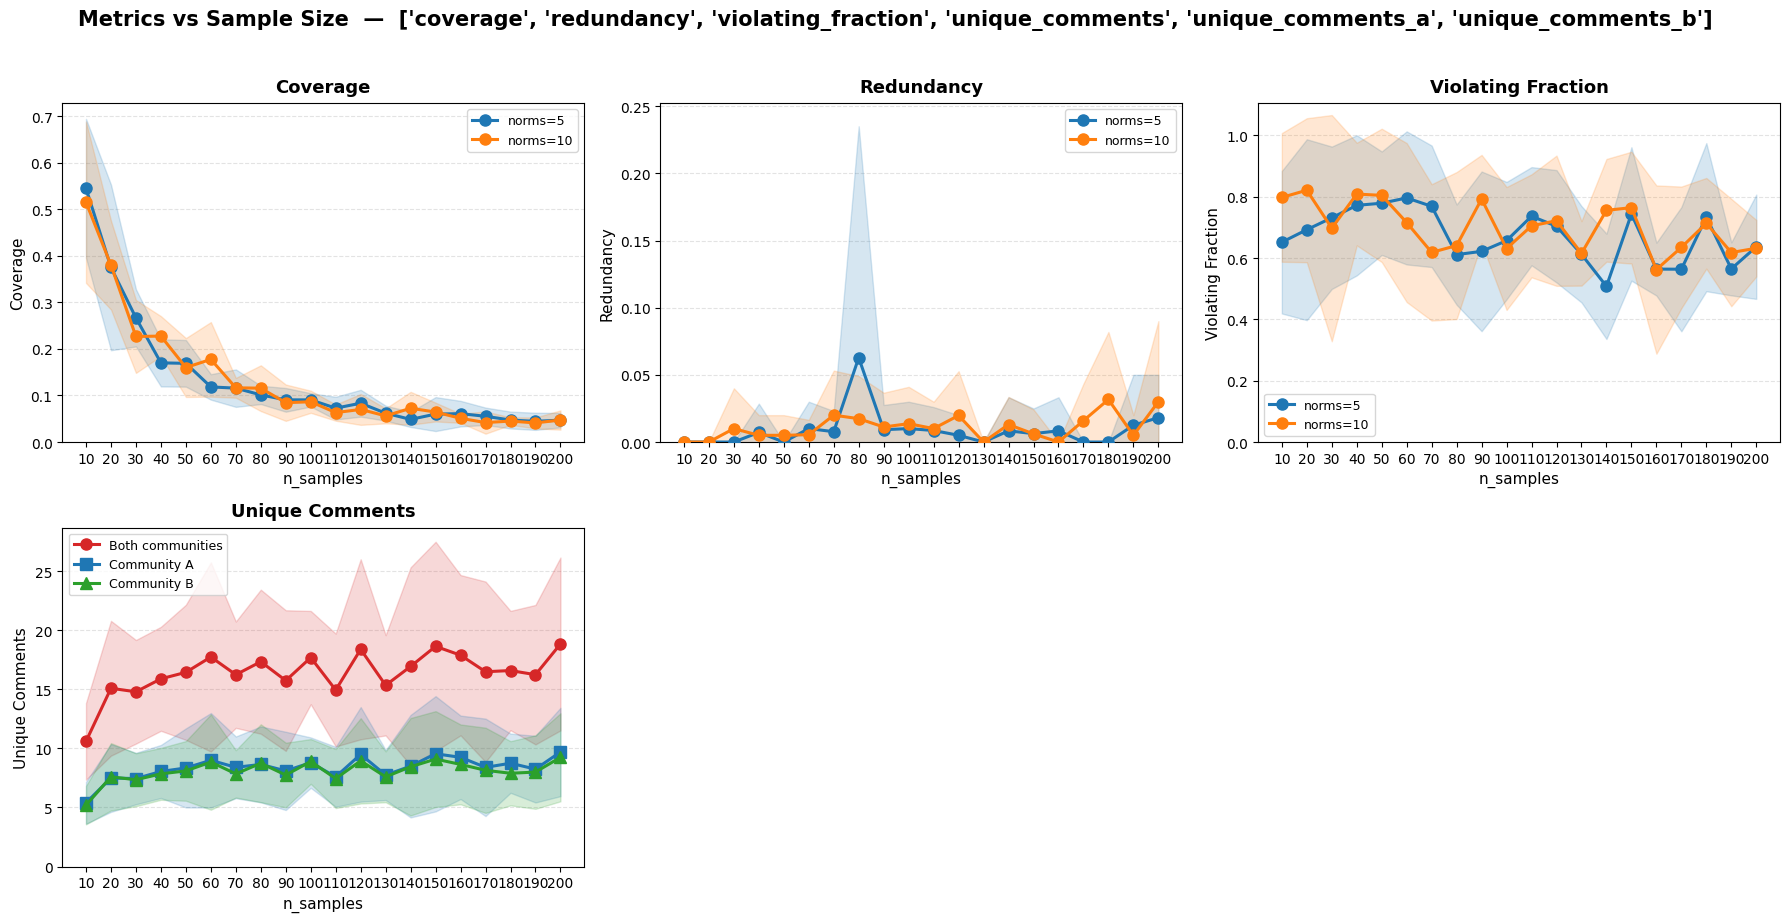

In [36]:
plot_metrics(records)